In [3]:
#Training: Gymasium CartPole-v1
#     A. Cart Position
#     B. Cart Velocity
#     C. Pole Angle
#     D. Pole Angular Velocity
#Model: neural network motion/ action predictor
#Goal: based on the current position/angle of the pole
#     A. Predict which direction the pole will fall
#     B. The optimal action to take to balance the pole
#1. Set up gymnasium
#2. Train a neural network with q learning to do the optimal actions to balance the pole
#3. create a separate network and train on pole angles with no corrective action
#4. Apply the second neural network’s optimal action choices to a new neural model
#5. Compare results between the two to prove relevancy of motion prediction.

In [4]:
%pip install -q -U gymnasium swig
%pip install -q -U gymnasium[classic_control,box2d,atari]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 66.1 MB/s eta 0:00:00


In [5]:
#IMPORTS

#py 3.7+
import sys
assert sys.version_info >= (3, 7)

#np
import numpy as np

#env value
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tf_keras

#tf 2.8+
from packaging import version
import tensorflow as tf
assert version.parse(tf.__version__) >= version.parse("2.8.0")

#dq
from collections import deque

#plt
import matplotlib.animation
import matplotlib.pyplot as plt

#Path (folder access)
from pathlib import Path

#Gymnasium (reinforcement learning/cartpole)
import gymnasium as gym

In [20]:
#SETUP

#tf (nn model)
tf.random.set_seed(42)
input_shape = [4]
n_outputs = 2
optimizer = tf.keras.optimizers.Nadam(learning_rate=1e-2)
loss_fn = tf.keras.losses.MeanSquaredError(reduction="sum")
model = tf.keras.Sequential([
    tf.keras.Input(shape=input_shape),
    tf.keras.layers.Dense(32, activation="elu"),
    tf.keras.layers.Dense(32, activation="elu"),
    tf.keras.layers.Dense(n_outputs)
])

motion_losses = []
motion_rewards = []
pmodel = tf.keras.Sequential([
    tf.keras.Input(shape=(3,)),
    tf.keras.layers.Dense(32, activation="elu"),
    tf.keras.layers.Dense(32, activation="elu"),
    tf.keras.layers.Dense(2)     #angle + velocity
])

optimizer_p = tf.keras.optimizers.Adam(1e-3)
loss_p = tf.keras.losses.MeanSquaredError()

#Q-LEARNING
np.random.seed(42)
transition_probabilities = [  # shape=[s, a, s']
    [[0.7, 0.3, 0.0], [1.0, 0.0, 0.0], [0.8, 0.2, 0.0]],
    [[0.0, 1.0, 0.0], None, [0.0, 0.0, 1.0]],
    [None, [0.8, 0.1, 0.1], None]
]
rewards = [  # shape=[s, a, s']
    [[+10, 0, 0], [0, 0, 0], [0, 0, 0]],
    [[0, 0, 0], [0, 0, 0], [0, 0, -50]],
    [[0, 0, 0], [+40, 0, 0], [0, 0, 0]]
]
possible_actions = [[0, 1, 2], [0, 2], [1]]
Q_values = np.full((3, 3), -np.inf)
for state, actions in enumerate(possible_actions):
    Q_values[state][actions] = 0

#rpb
replay_buffer = deque(maxlen=2000)

#plt
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('animation', html='jshtml')

#Gymnasium (cart + pole, Agent move cart to balance pole)
env = gym.make("CartPole-v1", render_mode="rgb_array")
env.reset(seed=42)
rewards = []
best_score = 0
pbest_score = 0
batch_size = 32
discount_factor = 0.95

#folder for notebook illustrations
IMAGES_PATH = Path() / "images" / "rl"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

In [7]:
#ILLUSTRATION FUNCTIONS

#save figures for notebook illustration
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

#cartpole render
def plot_environment(env, figsize=(5, 4)):
    plt.figure(figsize=figsize)
    img = env.render()
    plt.imshow(img)
    plt.axis("off")
    return img

def update_scene(num, frames, patch):
    patch.set_data(frames[num])
    return patch,

def plot_animation(frames, repeat=False, interval=40):
    fig = plt.figure()
    patch = plt.imshow(frames[0])
    plt.axis('off')
    anim = matplotlib.animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)
    plt.close()
    return anim

def show_one_episode(policy, n_max_steps=200, seed=42):
    frames = []
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    np.random.seed(seed)
    obs, info = env.reset(seed=seed)
    for step in range(n_max_steps):
        frames.append(env.render())
        action = policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        if done or truncated:
            break
    env.close()
    return plot_animation(frames)

In [8]:
# Q-LEARNING FUNCTIONS

def epsilon_greedy_policy(state, epsilon=0):
    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)  # random action
    else:
        Q_values = model.predict(state[np.newaxis], verbose=0)[0]
        return Q_values.argmax()  # optimal action according to the DQN

def play_one_step(env, state, epsilon):
    action = epsilon_greedy_policy(state, epsilon)
    next_state, reward, done, truncated, info = env.step(action)
    replay_buffer.append((state, action, reward, next_state, done, truncated))
    return next_state, reward, done, truncated, info

def sample_experiences(batch_size):
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[index] for index in indices]
    return [
        np.array([experience[field_index] for experience in batch])
        for field_index in range(6)
    ]

def training_step(batch_size):
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones, truncateds = experiences
    next_Q_values = model.predict(next_states, verbose=0)
    max_next_Q_values = next_Q_values.max(axis=1)
    runs = 1.0 - tf.cast(dones | truncateds, tf.float32)
    target_Q_values = rewards + runs * discount_factor * max_next_Q_values
    target_Q_values = tf.reshape(target_Q_values, (-1, 1))
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

In [21]:
#MOTION PREDICTION FUNCTIONS

def motion_policy(state):
    angle = state[2]
    ang_vel = state[3]
    best_action = 0
    best_score = float("inf")
    for action in [0,1]:
        inp = np.array([[angle, ang_vel, action]])
        pred_angle, pred_ang_vel = pmodel.predict(inp, verbose=0)[0]
        score = abs(pred_angle) + 0.7 * abs(pred_ang_vel)
        if score < best_score:
            best_score = score
            best_action = action
    return best_action

def train_motion_model(batch_size):
    if len(replay_buffer) < batch_size:
        return
    states, actions, rewards, next_states, dones, truncateds = sample_experiences(batch_size)
    angle = states[:,2]
    ang_vel = states[:,3]
    next_angle = next_states[:,2]
    next_ang_vel = next_states[:,3]
    inputs = np.stack([angle, ang_vel, actions], axis=1)
    targets = np.stack([next_angle, next_ang_vel], axis=1)
    with tf.GradientTape() as tape:
        pred = pmodel(inputs)
        loss = loss_p(targets, pred)
        motion_losses.append(loss)
    grads = tape.gradient(loss, pmodel.trainable_variables)
    optimizer_p.apply_gradients(zip(grads, pmodel.trainable_variables))


In [10]:
for episode in range(400):
    obs, info = env.reset()
    for step in range(200):
        epsilon = max(1 - episode / 200, 0.01)
        obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
        if done or truncated:
            break
    print(f"\rEpisode: {episode + 1}, Steps: {step + 1}, eps: {epsilon:.3f}",
          end="")
    rewards.append(step)
    if step >= best_score:
        best_weights = model.get_weights()
        best_score = step
    if episode > 50:
        training_step(batch_size)
model.set_weights(best_weights)  #reset

Episode: 52, Steps: 13, eps: 0.745

Episode: 400, Steps: 195, eps: 0.010

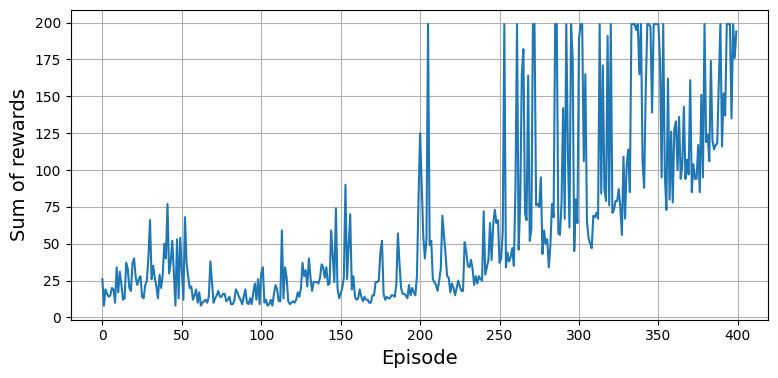

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(rewards)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.grid(True)
save_fig("dqn_rewards_plot")
plt.show()

In [12]:
show_one_episode(epsilon_greedy_policy)

In [25]:
for episode in range(400):
    state, _ = env.reset()
    total_reward = 0
    for step in range(200):
        action = motion_policy(state)
        next_state, reward, done, truncated, _ = env.step(action)
        replay_buffer.append((state, action, reward, next_state, done, truncated))
        state = next_state
        total_reward += reward
        if done or truncated:
            break
    print(f"Episode: {episode+1}, Steps: {step+1}, Buffer: {len(replay_buffer)+1}")
    motion_rewards.append(total_reward)
    if step >= pbest_score:
        pbest_weights = pmodel.get_weights()
        pbest_score = step
    if len(replay_buffer) > 1000 and episode < 150:
        train_motion_model(batch_size)
pmodel.set_weights(pbest_weights)  #reset

Episode: 1, Steps: 8, Buffer: 341
Episode: 2, Steps: 10, Buffer: 351
Episode: 3, Steps: 9, Buffer: 360
Episode: 4, Steps: 10, Buffer: 370
Episode: 5, Steps: 8, Buffer: 378
Episode: 6, Steps: 10, Buffer: 388
Episode: 7, Steps: 10, Buffer: 398
Episode: 8, Steps: 8, Buffer: 406
Episode: 9, Steps: 9, Buffer: 415
Episode: 10, Steps: 10, Buffer: 425
Episode: 11, Steps: 8, Buffer: 433
Episode: 12, Steps: 10, Buffer: 443
Episode: 13, Steps: 10, Buffer: 453
Episode: 14, Steps: 10, Buffer: 463
Episode: 15, Steps: 10, Buffer: 473
Episode: 16, Steps: 9, Buffer: 482
Episode: 17, Steps: 9, Buffer: 491
Episode: 18, Steps: 8, Buffer: 499
Episode: 19, Steps: 9, Buffer: 508
Episode: 20, Steps: 10, Buffer: 518
Episode: 21, Steps: 10, Buffer: 528
Episode: 22, Steps: 8, Buffer: 536
Episode: 23, Steps: 11, Buffer: 547
Episode: 24, Steps: 10, Buffer: 557
Episode: 25, Steps: 9, Buffer: 566
Episode: 26, Steps: 9, Buffer: 575
Episode: 27, Steps: 10, Buffer: 585
Episode: 28, Steps: 10, Buffer: 595
Episode: 29, S

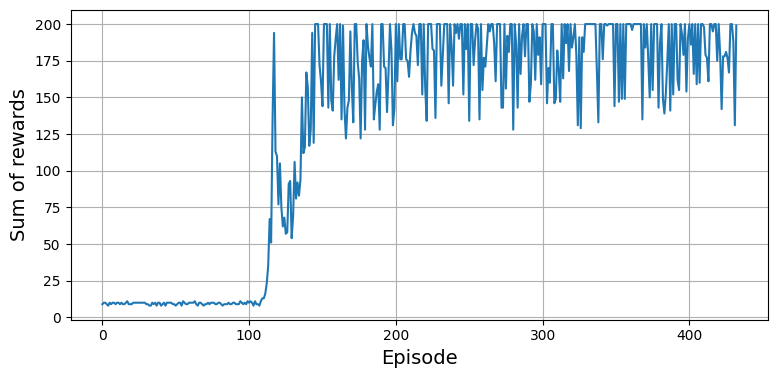

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(motion_rewards)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.grid(True)
save_fig("motion_rewards_plot")
plt.show()

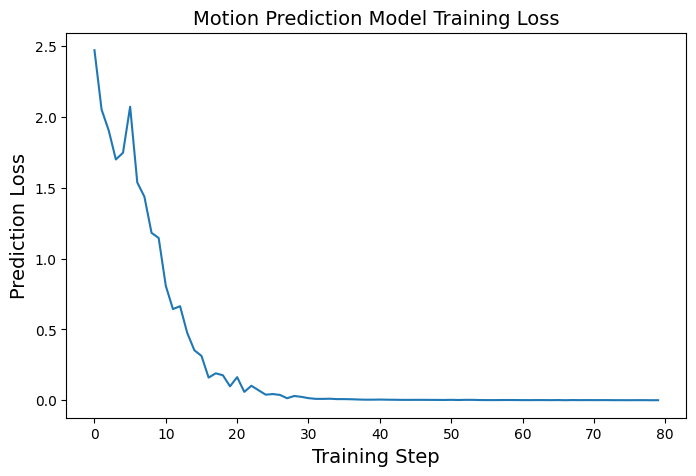

In [27]:
plt.figure(figsize=(8,5))
plt.plot(motion_losses)
plt.xlabel("Training Step")
plt.ylabel("Prediction Loss")
plt.title("Motion Prediction Model Training Loss")
plt.show()

In [28]:
show_one_episode(motion_policy)